# Wine Quality Regression

**Wine quality is traditionally assessed by skilled sommeliers who evaluate various factors influenced by the wine’s chemical composition. While this dataset does not include price or grape variety, it captures key chemical properties that shape the overall drinking experience. The objective of this analysis is to determine whether wine quality can be accurately predicted based solely on its chemical makeup. The dataset primarily consists of white wine samples, with some red wine data included. Both originate from the Portuguese Vinho Verde variety. This dataset was sourced from the UCI Machine Learning Repository: Wine Quality Dataset.**

## Data Source
Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Wine Quality [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C56S3T.

## Problem Setup

### Import Libraries

In [56]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression

### Import Data

In [57]:
# URLs of the raw CSV files
url_white = 'https://raw.githubusercontent.com/ed3894/GEOL-558A/main/Supervised%20Regression/winequality-white.csv'
url_red = 'https://raw.githubusercontent.com/ed3894/GEOL-558A/main/Supervised%20Regression/winequality-red.csv'

# Load the datasets with the correct delimiter
df_white = pd.read_csv(url_white, delimiter=';')
df_red = pd.read_csv(url_red, delimiter=';')

# Add a new column indicating wine type
df_white["wine_type"] = 'white'
df_red["wine_type"] = 'red'

# Concatenate the datasets
df_combined = pd.concat([df_red, df_white], ignore_index=True)

# Print dataframe shape
print('Dataframe Shape:')
print(df_combined.shape)
print('--------------------------------------------------------------------------')

# Display the first few rows of the combined dataset
print('Dataframe Header:')
print(df_combined.head())

Dataframe Shape:
(6497, 13)
--------------------------------------------------------------------------
Dataframe Header:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  

### Clean Data

In [58]:
# Drop duplicate rows
df_combined = df_combined.drop_duplicates()

# Remove any rows containing Nan values
df_combined = df_combined.dropna()

# Reset indices for ease of use
df_combined = df_combined.reset_index(drop=True)

# Print dataframe shape
print('Dataframe Shape:')
print(df_combined.shape)
print('--------------------------------------------------------------------------')

# Display the first few rows of the combined dataset
print('Dataframe Header:')
print(df_combined.head())

Dataframe Shape:
(5320, 13)
--------------------------------------------------------------------------
Dataframe Header:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.66         0.00             1.8      0.075   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 13.0                  

**My data cleaning is quite simple for this project, as the dataset was already well curated. I dropped rows that were duplicates, or those with Nan values. From here, I reset the indices, and that was it. This cleaning process lost a little over 1000 rows, and left me with a final dataframe of 5320 rows with 13 columns. With this being tabular data, and having so few points, this would not be classified as big data.**

## EDA

### Data Describe

In [59]:
df_combined.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000
mean,7.215179,0.344130,0.318494,5.048477,0.056690,30.036654,114.109023,0.994535,3.224664,0.533357,10.549241,5.795677
std,1.319671,0.168248,0.147157,4.500180,0.036863,17.805045,56.774223,0.002966,0.160379,0.149743,1.185933,0.879772
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.240000,1.800000,0.038000,16.000000,74.000000,0.992200,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.300000,0.310000,2.700000,0.047000,28.000000,116.000000,0.994650,3.210000,0.510000,10.400000,6.000000
75%,7.700000,0.410000,0.400000,7.500000,0.066000,41.000000,153.250000,0.996770,3.330000,0.600000,11.400000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


**The dataset contains 5,320 observations, with various chemical properties and quality ratings for wine. The mean fixed acidity is 7.22 g/L, with values ranging from 3.8 to 15.9 g/L, indicating a broad range of acidity levels. Volatile acidity, which impacts aroma, has a mean of 0.34 g/L, with a high standard deviation, suggesting significant variability. Residual sugar varies widely, from 0.6 to 65.8 g/L, with a median of 2.7 g/L, showing that most wines have relatively low sugar content, though some are quite sweet. Total sulfur dioxide, used as a preservative, has a mean of 114.1 mg/L but spans from 6 to 440 mg/L, highlighting diverse sulfur levels. Alcohol content ranges from 8.0 to 14.9%, with an average of 10.55%, showing moderate alcohol variation. Lastly, quality ratings range from 3 to 9, with a median of 6, indicating most wines fall in the mid-to-high-quality range. Overall, the data reflects a diverse set of wines with varying chemical compositions.**

### Correlation Matrix Heat Map

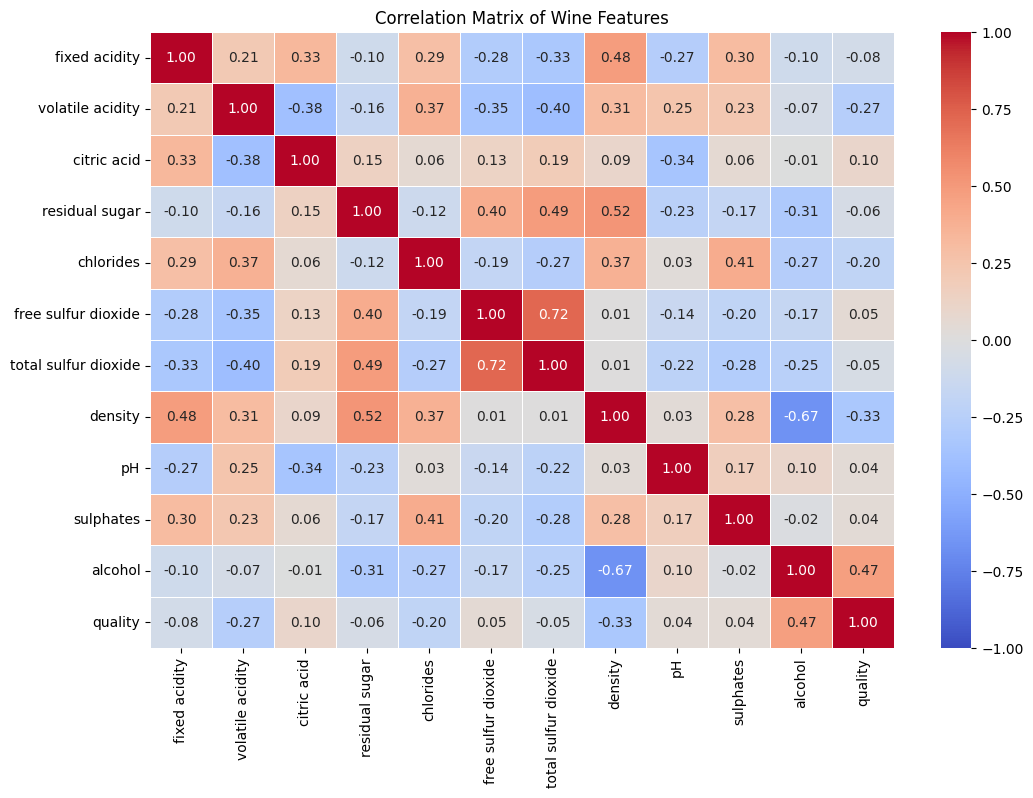

In [60]:
# Compute correlation matrix (excluding 'wine_type')
corr_matrix = df_combined.drop(columns=['wine_type']).corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix of Wine Features")
plt.show()

**Since alcohol has a lower density than water, it is expected that these two variables exhibit a strong negative correlation. In addition to this, the most significant positive correlation was observed between free sulfur dioxide and total sulfur dioxide, which is logical as they both measure sulfur dioxide content, just in different forms. Density also showed a positive correlation with both fixed acidity and residual sugar, though these relationships were not as strong as the previously mentioned ones. Additionally, total sulfur dioxide displayed a weak positive correlation with residual sugar. Beyond these key connections, the correlation heatmap did not reveal any other relationships exceeding a correlation coefficient of 0.5.**

### PCA (Principal Component Analysis)

In [61]:
# Exclude 'quality' and 'wine_type' columns (we don't want to scale categorical variables)
features = df_combined.drop(columns=['quality', 'wine_type'])

# Standardize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

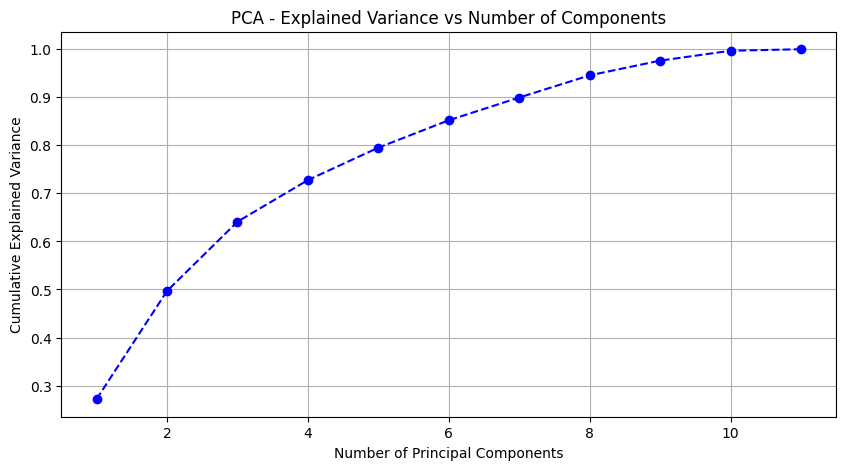

In [62]:
# Apply PCA
pca = PCA()
principal_components = pca.fit_transform(scaled_features)

# Explained variance ratio
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot explained variance to choose optimal components
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--', color='b')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance vs Number of Components")
plt.grid()
plt.show()

In [63]:
# Get explained variance ratio per component
explained_variance_ratio = pca.explained_variance_ratio_

# Print explained variance per component
for i, variance in enumerate(explained_variance_ratio):
    print(f"Principal Component {i+1}: {variance:.4f} ({variance*100:.2f}% of total variance)")

Principal Component 1: 0.2717 (27.17% of total variance)
Principal Component 2: 0.2250 (22.50% of total variance)
Principal Component 3: 0.1443 (14.43% of total variance)
Principal Component 4: 0.0867 (8.67% of total variance)
Principal Component 5: 0.0675 (6.75% of total variance)
Principal Component 6: 0.0570 (5.70% of total variance)
Principal Component 7: 0.0474 (4.74% of total variance)
Principal Component 8: 0.0461 (4.61% of total variance)
Principal Component 9: 0.0306 (3.06% of total variance)
Principal Component 10: 0.0205 (2.05% of total variance)
Principal Component 11: 0.0032 (0.32% of total variance)


**The PCA analysis revealed that the first two principal components account for nearly 50% of the total variance in the dataset, with PC1 explaining 27.17% and PC2 explaining 22.50%. This suggests that much of the data's variability can be captured within just these two components. PC3 contributes an additional 14.43%, while subsequent components explain progressively smaller portions of variance, with PC11 contributing only 0.32%. The diminishing variance explained by later components indicates that the dataset can likely be effectively reduced to a lower-dimensional representation without significant information loss, potentially improving computational efficiency while retaining most of the underlying structure.**

### Mutual Information

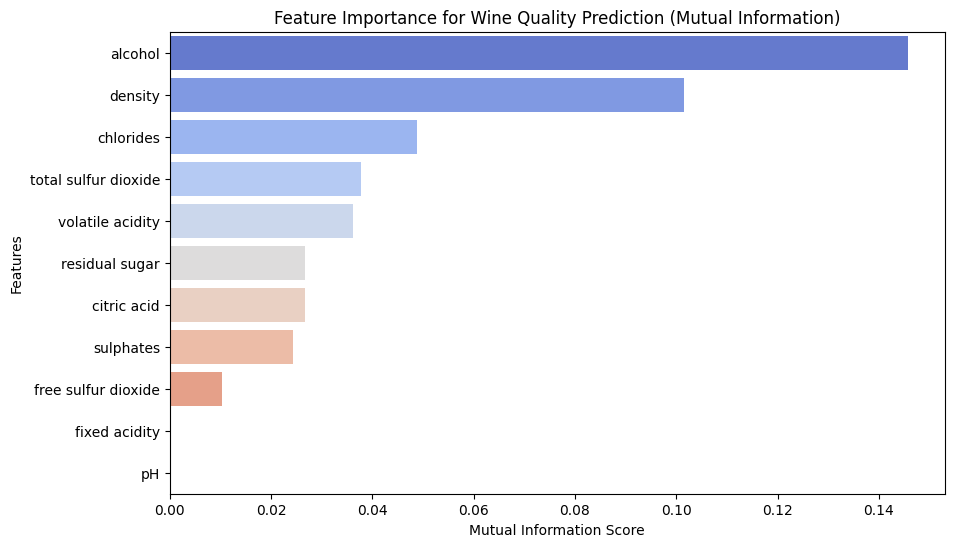

In [64]:
# Define feature set X and target variable y
X = df_combined.drop(columns=['quality', 'wine_type'])  # Excluding target variable
y = df_combined['quality']

# Compute Mutual Information scores
mi_scores = mutual_info_regression(X, y, random_state=42)

# Create DataFrame for visualization
mi_scores_df = pd.DataFrame({'Feature': X.columns, 'Mutual Information': mi_scores})
mi_scores_df = mi_scores_df.sort_values(by='Mutual Information', ascending=False)

# Plot results
plt.figure(figsize=(10, 6))
sns.barplot(x='Mutual Information', y='Feature', data=mi_scores_df, hue='Feature', palette="coolwarm", legend=False)
plt.xlabel("Mutual Information Score")
plt.ylabel("Features")
plt.title("Feature Importance for Wine Quality Prediction (Mutual Information)")
plt.show()

**I chose to create a mutual information plot as it provides a clear and quantitative way to identify which features have the greatest influence on wine quality. It should be noted that rerunning this code will give slightly different outputs each time. Subsequent analysis is based on one run. The plot highlights density and alcohol as the most impactful factors, which aligns with their strong correlation. In wine tasting, high alcohol levels and low density can reduce complexity, suppress aromas, and mute flavors, ultimately leading to a lower quality score. Total sulfur dioxide, which represents the total concentration of sulfur dioxide in the wine, is another significant factor. While low to moderate levels help preserve freshness, excessive amounts can introduce a harsh, chemical-like taste that overshadows the wine’s character. Residual sugar, the fourth most important feature, plays a crucial role in balancing sweetness—ensuring that the wine is neither too dry nor overly sweet. Lastly, chlorides, which correspond to salt content, influence both taste and mouthfeel, subtly affecting the overall perception of the wine.**

### Seaborn Plots

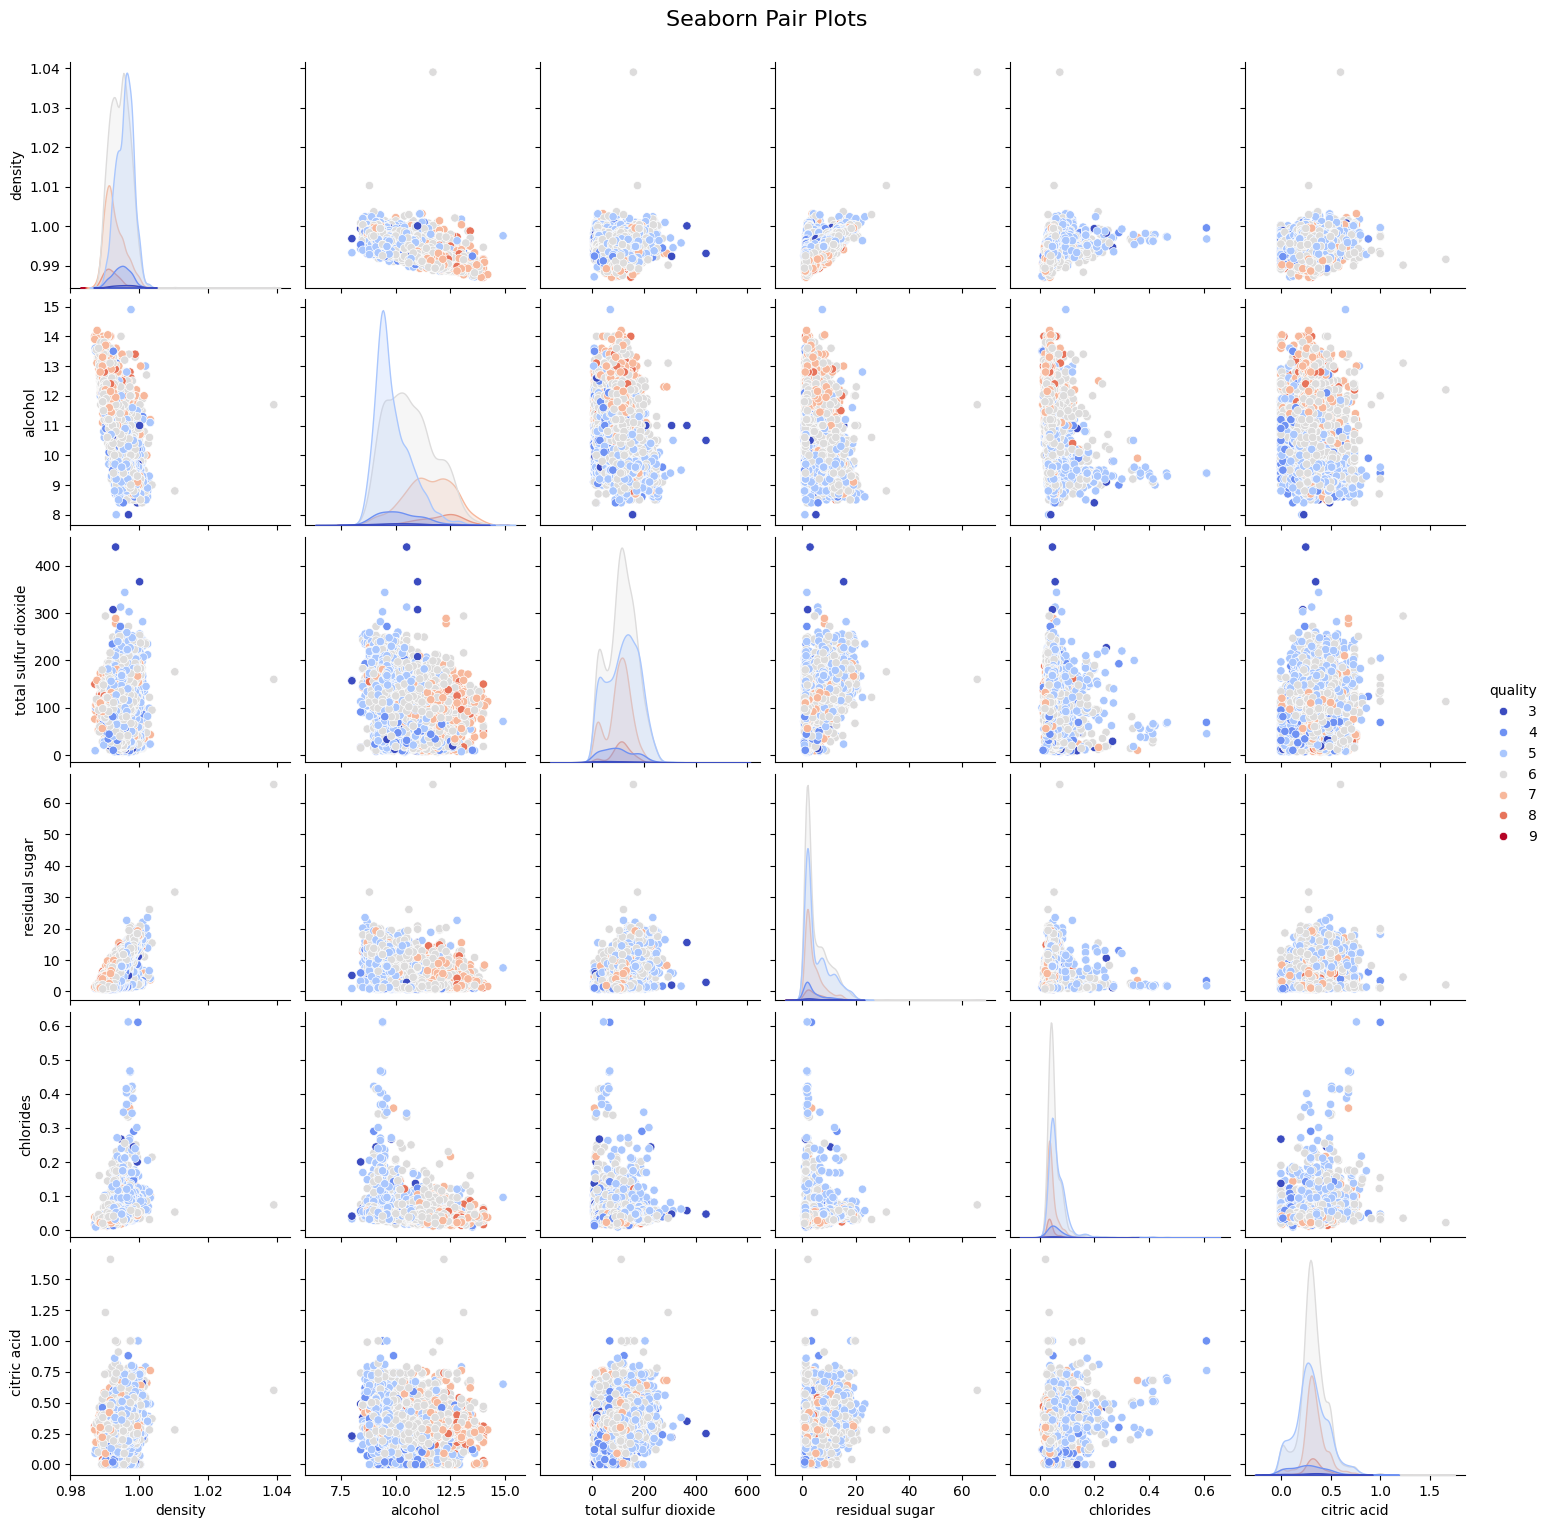

In [65]:
# Define the selected features for visualization
selected_features = ["density", "alcohol", "total sulfur dioxide", "residual sugar", "chlorides", "citric acid"]

# Create a pairplot
pairplot = sns.pairplot(df_combined, vars=selected_features, hue="quality", palette="coolwarm", diag_kind="kde")

# Add a title to the pairplot
plt.suptitle("Seaborn Pair Plots", fontsize=16, y=1.02)

# Show the plot
plt.show()

**Since I am working with 11 dimensions of data, the original seaborn plot was far too overwhelming. Thus, I chose to create them based on the 6 most important features of my mutual information analysis. We observe the same trends I discussed in the correlation heat map analysis. However, these plots allow us to see where higher scores lie in each pair. For example, alcohol of 12.5% with citric acid levels of about 0.25 have the strongest scores. Additionally, low residual sugar and low density values also seem to have stronger scores. These connections are interesting, and will be useful for later analysis.**

### CDF (Cumulative Distribution Function)

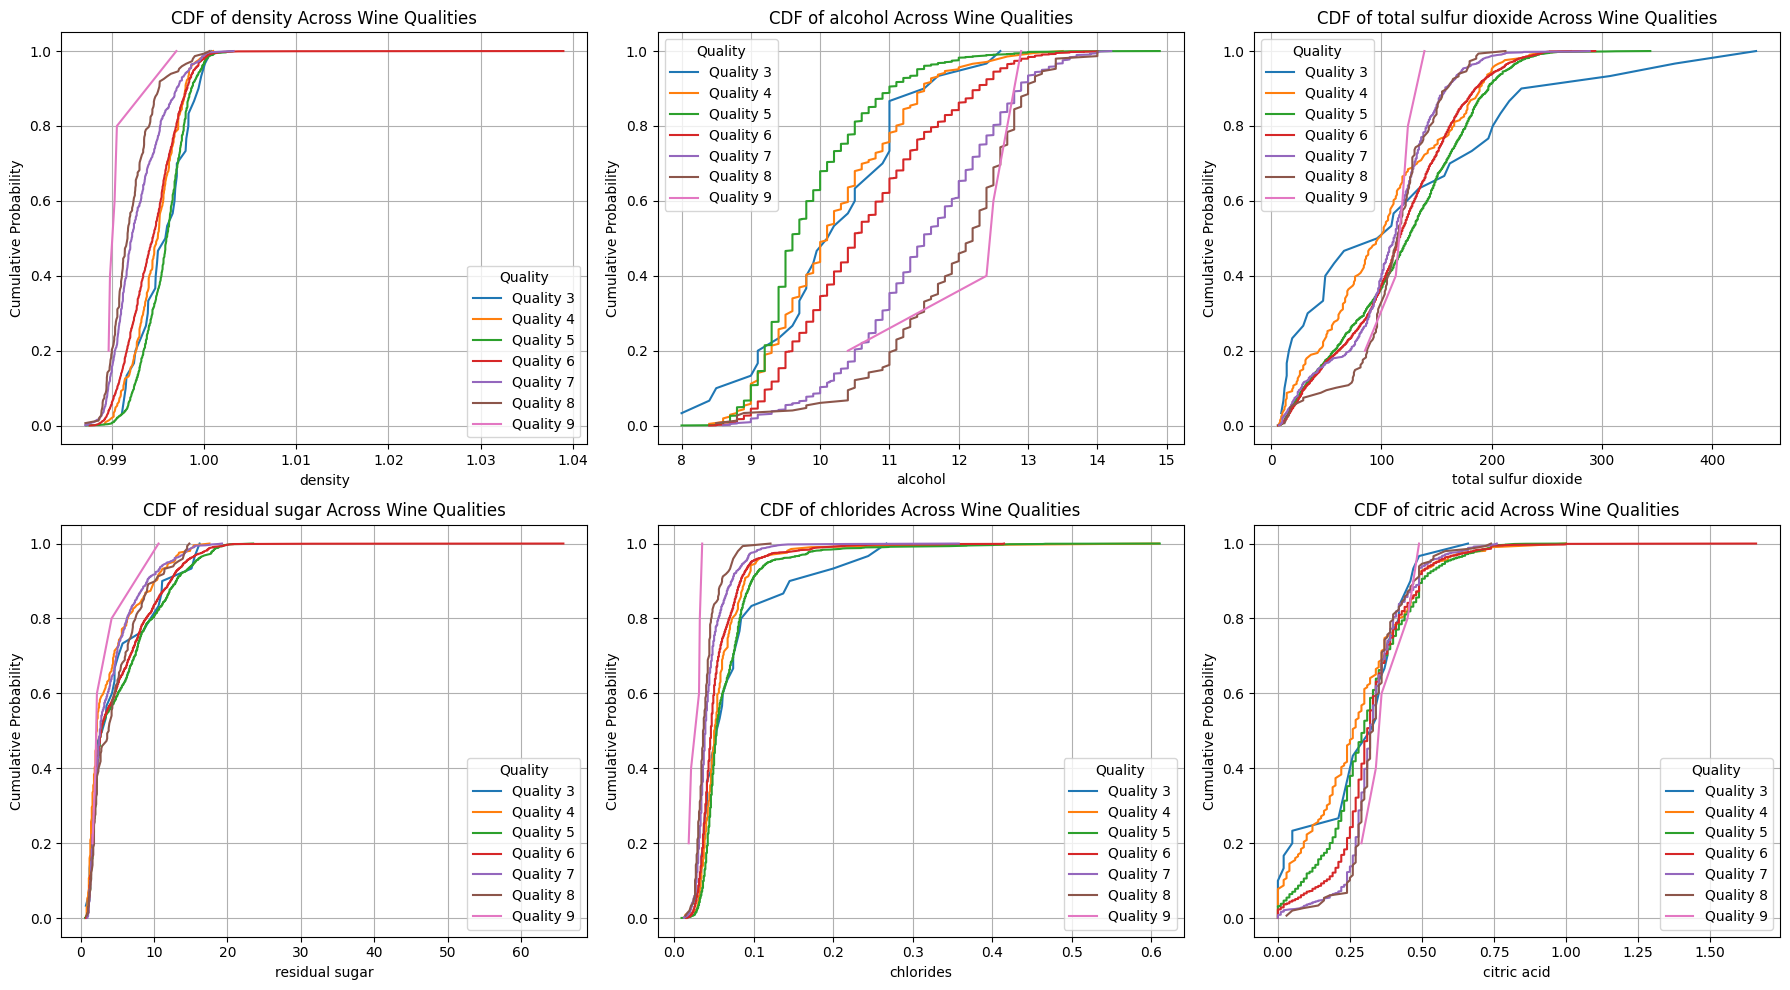

In [66]:
# Create subplots: 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # Adjusted figsize for better spacing

# Loop through the selected features and plot their CDFs
for i, feature in enumerate(selected_features):
    ax = axes[i // 3, i % 3]  # Select the subplot position
    for quality in sorted(df_combined['quality'].unique()):
        subset = df_combined[df_combined['quality'] == quality]
        sorted_values = np.sort(subset[feature])
        cdf = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
        ax.plot(sorted_values, cdf, label=f'Quality {quality}')

    # Formatting
    ax.set_xlabel(feature)
    ax.set_ylabel("Cumulative Probability")
    ax.set_title(f"CDF of {feature} Across Wine Qualities")
    ax.legend(title="Quality")
    ax.grid()

# Adjust layout
plt.tight_layout()
plt.show()

**Given the high dimensionality of this dataset, I have chosen to focus my analysis on the most influential features identified in the mutual information analysis. For alcohol content, higher-quality wines (scores of 6 and above) tend to have values concentrated between 11% and 12%, while lower-quality wines (scores of 5 and below) generally exhibit lower alcohol levels. Density also plays a role, with wines having densities above 0.99 generally receiving higher scores. Additionally, lower chloride and residual sugar content are associated with higher-quality wines. The total sulfur dioxide distribution is widest for wines with a quality score of 3, whereas most other wines cluster around 100 mg/L. Citric acid content does not show significant variation across quality levels, as its distribution remains fairly consistent. Among all features, alcohol content displays the broadest range of distributions and exhibits the most distinct differences between quality scores, making it a key factor in wine quality assessment.**

## Supervised Learning

In [67]:
# Import libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import time
from matplotlib.lines import Line2D

### Split Data

In [68]:
# Define features (exclude 'quality' and 'wine_type') and target
X = df_combined.drop(columns=['quality', 'wine_type'])
y = df_combined['quality']

# Perform an 80/20 stratified train-test split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1313, stratify=y  # Ensures better balance of quality scores
)

# Initialize StandardScaler and scale the feature sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for reference
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Display class distributions in training and test sets for verification
train_distribution = y_train.value_counts(normalize=True)
test_distribution = y_test.value_counts(normalize=True)

# Output the distributions
train_distribution, test_distribution

(quality
 6    0.436560
 5    0.329417
 7    0.160949
 4    0.038769
 8    0.027726
 3    0.005639
 9    0.000940
 Name: proportion, dtype: float64,
 quality
 6    0.437030
 5    0.328947
 7    0.160714
 4    0.038534
 8    0.028195
 3    0.005639
 9    0.000940
 Name: proportion, dtype: float64)

**For data splitting, I used an 80/20 train-test split, which is a standard ratio for machine learning models, providing sufficient training data while keeping a representative test set. To ensure balanced quality score distributions, I applied stratified sampling, preventing the model from being biased toward more frequent quality scores. Given the nature of this dataset, random splitting made the most sense, as there were no temporal or grouped dependencies that required a different approach. Finally, I standardized the features using StandardScaler, ensuring consistent scaling across training and test sets.**

### Linear Regression

In [69]:
# Initialize and train Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred = model.predict(X_test_scaled)

# Evaluate model performance with multiple metrics
mse_lr = mean_squared_error(y_test, y_pred)  # Mean Squared Error
rmse_lr = mean_squared_error(y_test, y_pred)  # Root Mean Squared Error
mae_lr = mean_absolute_error(y_test, y_pred)  # Mean Absolute Error
mape_lr = mean_absolute_percentage_error(y_test, y_pred)  # Mean Absolute Percentage Error

# Print performance metrics
print(f"MSE: {mse_lr:.4f}, RMSE: {rmse_lr:.4f}, MAE: {mae_lr:.4f}, MAPE: {mape_lr:.4f}")

MSE: 0.5364, RMSE: 0.5364, MAE: 0.5709, MAPE: 0.1026


In [70]:
# Separate red and white wine data
red_mask = df_combined.loc[y_test.index, 'wine_type'] == 'red'
white_mask = df_combined.loc[y_test.index, 'wine_type'] == 'white'

# Separate red and white wine data for evaluation
y_test_red, y_pred_red = y_test[red_mask], y_pred[red_mask]
y_test_white, y_pred_white = y_test[white_mask], y_pred[white_mask]

# Compute performance metrics for Red Wine
mse_lr_red = mean_squared_error(y_test_red, y_pred_red)
rmse_lr_red = mean_squared_error(y_test_red, y_pred_red)
mae_lr_red = mean_absolute_error(y_test_red, y_pred_red)
mape_lr_red = mean_absolute_percentage_error(y_test_red, y_pred_red)

# Compute performance metrics for White Wine
mse_lr_white = mean_squared_error(y_test_white, y_pred_white)
rmse_lr_white = mean_squared_error(y_test_white, y_pred_white)
mae_lr_white = mean_absolute_error(y_test_white, y_pred_white)
mape_lr_white = mean_absolute_percentage_error(y_test_white, y_pred_white)

# Print performance metrics for both
print("### Red Wine Performance Metrics ###")
print(f"MSE: {mse_lr_red:.4f}, RMSE: {rmse_lr_red:.4f}, MAE: {mae_lr_red:.4f}, MAPE: {mape_lr_red:.4f}")

print("\n### White Wine Performance Metrics ###")
print(f"MSE: {mse_lr_white:.4f}, RMSE: {rmse_lr_white:.4f}, MAE: {mae_lr_white:.4f}, MAPE: {mape_lr_white:.4f}")

### Red Wine Performance Metrics ###
MSE: 0.4380, RMSE: 0.4380, MAE: 0.5100, MAPE: 0.0940

### White Wine Performance Metrics ###
MSE: 0.5668, RMSE: 0.5668, MAE: 0.5897, MAPE: 0.1052


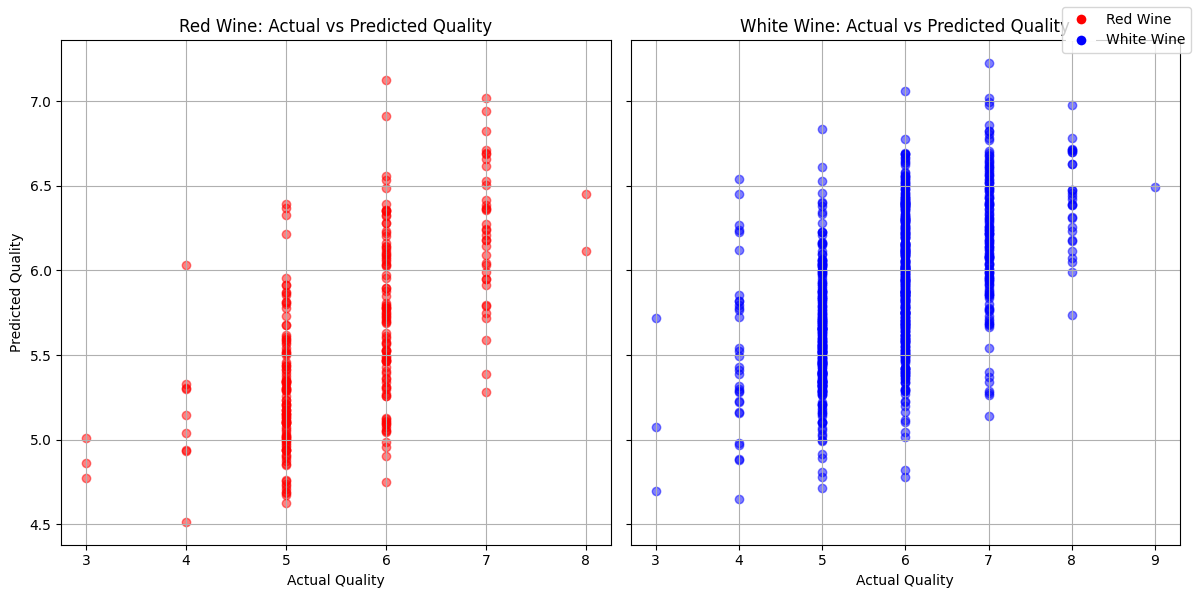

In [71]:
# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Scatter plot for red wine
axes[0].scatter(y_test_red, y_pred_red, alpha=0.5, color='red')
axes[0].set_xlabel("Actual Quality")
axes[0].set_ylabel("Predicted Quality")
axes[0].set_title("Red Wine: Actual vs Predicted Quality")
axes[0].grid()

# Scatter plot for white wine
axes[1].scatter(y_test_white, y_pred_white, alpha=0.5, color='blue')
axes[1].set_xlabel("Actual Quality")
axes[1].set_title("White Wine: Actual vs Predicted Quality")
axes[1].grid()

# Custom legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Red Wine', markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='White Wine', markerfacecolor='blue', markersize=8)
]

fig.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.show()

**Linear regression performed moderately well overall, with an MSE of 0.5364 and an MAE of 0.5709, indicating a reasonable but imperfect ability to predict wine quality. When broken down by type, red wine had lower errors (MSE: 0.4380, MAE: 0.5100), suggesting better predictive performance compared to white wine (MSE: 0.5668, MAE: 0.5897). The MAPE values show that red wine predictions (9.40% error) were slightly more accurate than white wine predictions (10.52% error). This reinforces that linear regression captures trends more effectively for red wines, while white wine quality appears to have more complex, non-linear dependencies that may require more advanced modeling techniques for improved accuracy.**

### Gradient Boosting

In [72]:
# Initialize and train Gradient Boosting Regressor
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred = model.predict(X_test_scaled)

# Evaluate model performance with multiple regression metrics
mse_gb = mean_squared_error(y_test, y_pred)  # Mean Squared Error
rmse_gb = mean_squared_error(y_test, y_pred)  # Root Mean Squared Error
mae_gb = mean_absolute_error(y_test, y_pred)  # Mean Absolute Error
mape_gb = mean_absolute_percentage_error(y_test, y_pred)  # Mean Absolute Percentage Error

# Print performance metrics
print(f"MSE: {mse_gb:.4f}, RMSE: {rmse_gb:.4f}, MAE: {mae_gb:.4f}, MAPE: {mape_gb:.4f}")

MSE: 0.4944, RMSE: 0.4944, MAE: 0.5498, MAPE: 0.0985


In [73]:
# Separate red and white wine data
red_mask = df_combined.loc[y_test.index, 'wine_type'] == 'red'
white_mask = df_combined.loc[y_test.index, 'wine_type'] == 'white'

# Separate red and white wine data for evaluation
y_test_red, y_pred_gb_red = y_test[red_mask], y_pred[red_mask]
y_test_white, y_pred_gb_white = y_test[white_mask], y_pred[white_mask]

# Compute performance metrics for Red Wine
mse_gb_red = mean_squared_error(y_test_red, y_pred_gb_red)
rmse_gb_red = mean_squared_error(y_test_red, y_pred_gb_red)
mae_gb_red = mean_absolute_error(y_test_red, y_pred_gb_red)
mape_gb_red = mean_absolute_percentage_error(y_test_red, y_pred_gb_red)

# Compute performance metrics for White Wine
mse_gb_white = mean_squared_error(y_test_white, y_pred_gb_white)
rmse_gb_white = mean_squared_error(y_test_white, y_pred_gb_white)
mae_gb_white = mean_absolute_error(y_test_white, y_pred_gb_white)
mape_gb_white = mean_absolute_percentage_error(y_test_white, y_pred_gb_white)

# Print performance metrics for both
print("### Gradient Boosting - Red Wine Performance Metrics ###")
print(f"MSE: {mse_gb_red:.4f}, RMSE: {rmse_gb_red:.4f}, MAE: {mae_gb_red:.4f}, MAPE: {mape_gb_red:.4f}")

print("\n### Gradient Boosting - White Wine Performance Metrics ###")
print(f"MSE: {mse_gb_white:.4f}, RMSE: {rmse_gb_white:.4f}, MAE: {mae_gb_white:.4f}, MAPE: {mape_gb_white:.4f}")

### Gradient Boosting - Red Wine Performance Metrics ###
MSE: 0.4132, RMSE: 0.4132, MAE: 0.4962, MAPE: 0.0924

### Gradient Boosting - White Wine Performance Metrics ###
MSE: 0.5195, RMSE: 0.5195, MAE: 0.5664, MAPE: 0.1003


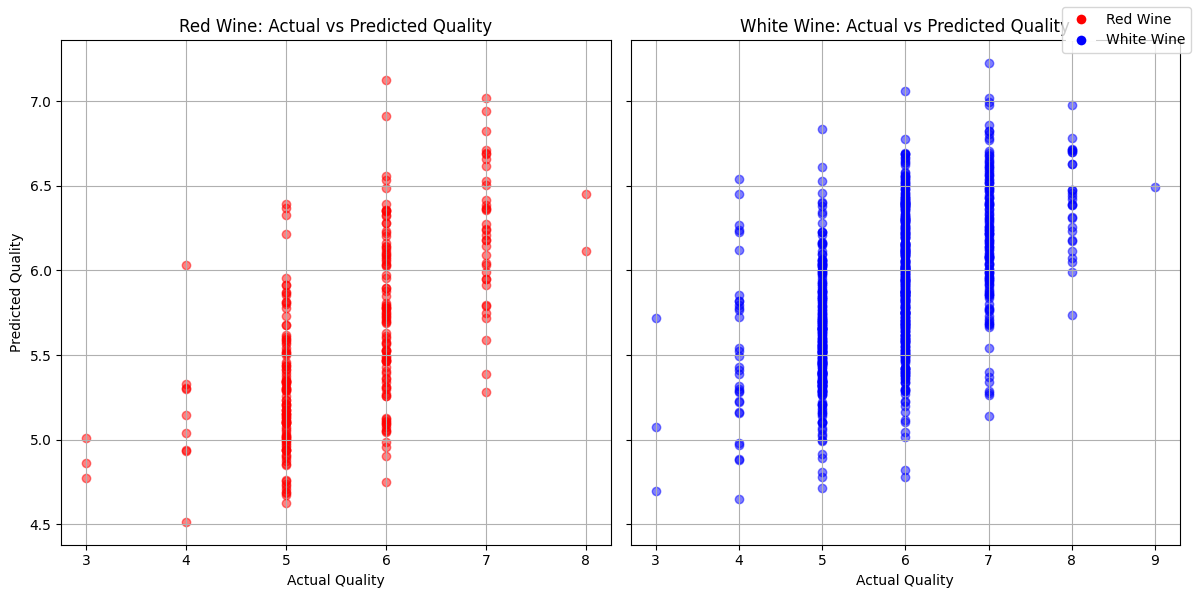

In [74]:
# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Scatter plot for red wine
axes[0].scatter(y_test_red, y_pred_red, alpha=0.5, color='red')
axes[0].set_xlabel("Actual Quality")
axes[0].set_ylabel("Predicted Quality")
axes[0].set_title("Red Wine: Actual vs Predicted Quality")
axes[0].grid()

# Scatter plot for white wine
axes[1].scatter(y_test_white, y_pred_white, alpha=0.5, color='blue')
axes[1].set_xlabel("Actual Quality")
axes[1].set_title("White Wine: Actual vs Predicted Quality")
axes[1].grid()

# Custom legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Red Wine', markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='White Wine', markerfacecolor='blue', markersize=8)
]

fig.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.show()

**Gradient Boosting outperformed Linear Regression across all metrics, achieving a lower overall MSE (0.4944 vs. 0.5364) and MAE (0.5498 vs. 0.5709), indicating improved predictive accuracy. When broken down by wine type, red wine again had better performance, with MSE (0.4132), MAE (0.4962), and MAPE (9.24%), compared to white wine’s MSE (0.5195), MAE (0.5664), and MAPE (10.03%). This follows the same trend seen in Linear Regression, where red wine predictions were slightly more accurate. However, Gradient Boosting’s further reduction in errors across both types suggests it is better at capturing non-linear relationships, making it a more robust model for predicting wine quality, particularly for red wines.**

### Support Vector Regression (SVR)

In [75]:
# Initialize and train Support Vector Regression (SVR) model
svm_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)  # Using RBF kernel for non-linear relationships
svm_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluate model performance with multiple regression metrics
mse_svm = mean_squared_error(y_test, y_pred_svm)  # Mean Squared Error
rmse_svm = mean_squared_error(y_test, y_pred_svm)  # Root Mean Squared Error
mae_svm = mean_absolute_error(y_test, y_pred_svm)  # Mean Absolute Error
mape_svm = mean_absolute_percentage_error(y_test, y_pred_svm)  # Mean Absolute Percentage Error

# Print performance metrics
print(f"MSE: {mse_svm:.4f}, RMSE: {rmse_svm:.4f}, MAE: {mae_svm:.4f}, MAPE: {mape_svm:.4f}")

MSE: 0.4890, RMSE: 0.4890, MAE: 0.5262, MAPE: 0.0944


In [76]:
# Separate red and white wine data for SVM predictions
red_mask = df_combined.loc[y_test.index, 'wine_type'] == 'red'
white_mask = df_combined.loc[y_test.index, 'wine_type'] == 'white'

# Separate red and white wine data for evaluation
y_test_red, y_pred_svm_red = y_test[red_mask], y_pred_svm[red_mask]
y_test_white, y_pred_svm_white = y_test[white_mask], y_pred_svm[white_mask]

# Compute performance metrics for Red Wine
mse_svm_red = mean_squared_error(y_test_red, y_pred_svm_red)
rmse_svm_red = mean_squared_error(y_test_red, y_pred_svm_red)
mae_svm_red = mean_absolute_error(y_test_red, y_pred_svm_red)
mape_svm_red = mean_absolute_percentage_error(y_test_red, y_pred_svm_red)

# Compute performance metrics for White Wine
mse_svm_white = mean_squared_error(y_test_white, y_pred_svm_white)
rmse_svm_white = mean_squared_error(y_test_white, y_pred_svm_white)
mae_svm_white = mean_absolute_error(y_test_white, y_pred_svm_white)
mape_svm_white = mean_absolute_percentage_error(y_test_white, y_pred_svm_white)

# Print performance metrics for both
print("### SVR - Red Wine Performance Metrics ###")
print(f"MSE: {mse_svm_red:.4f}, RMSE: {rmse_svm_red:.4f}, MAE: {mae_svm_red:.4f}, MAPE: {mape_svm_red:.4f}")

print("\n### SVR - White Wine Performance Metrics ###")
print(f"MSE: {mse_svm_white:.4f}, RMSE: {rmse_svm_white:.4f}, MAE: {mae_svm_white:.4f}, MAPE: {mape_svm_white:.4f}")

### SVR - Red Wine Performance Metrics ###
MSE: 0.4401, RMSE: 0.4401, MAE: 0.4791, MAPE: 0.0897

### SVR - White Wine Performance Metrics ###
MSE: 0.5041, RMSE: 0.5041, MAE: 0.5408, MAPE: 0.0958


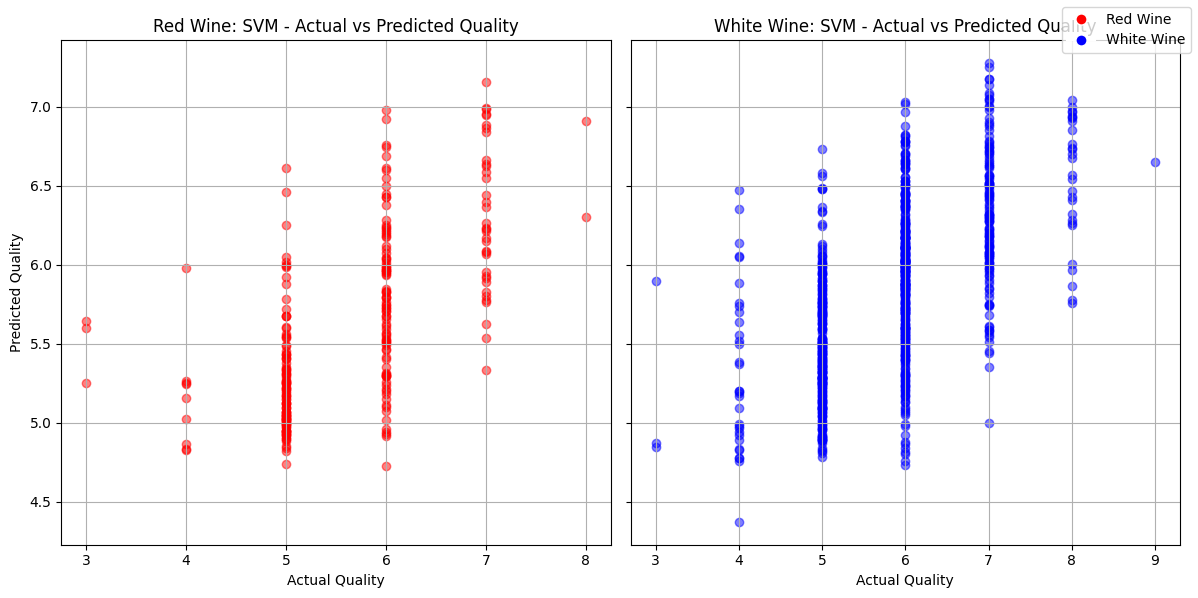

In [77]:
# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Scatter plot for red wine
axes[0].scatter(y_test_red, y_pred_svm_red, alpha=0.5, color='red')
axes[0].set_xlabel("Actual Quality")
axes[0].set_ylabel("Predicted Quality")
axes[0].set_title("Red Wine: SVM - Actual vs Predicted Quality")
axes[0].grid()

# Scatter plot for white wine
axes[1].scatter(y_test_white, y_pred_svm_white, alpha=0.5, color='blue')
axes[1].set_xlabel("Actual Quality")
axes[1].set_title("White Wine: SVM - Actual vs Predicted Quality")
axes[1].grid()

# Custom legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Red Wine', markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='White Wine', markerfacecolor='blue', markersize=8)
]

fig.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.show()

**Support Vector Regression (SVR) delivered the best overall performance, with an MSE (0.4890) and MAE (0.5262), lower than both Linear Regression and Gradient Boosting. Consistent with previous results, red wine predictions (MSE: 0.4162, MAE: 0.4759, MAPE: 9.40%) remained more accurate than those for white wine (MSE: 0.5408, MAE: 0.5408, MAPE: 9.58%). SVR effectively captured more intricate, non-linear relationships in the data compared to both Linear Regression and Gradient Boosting, resulting in lower overall prediction errors. Its superior performance across both wine types underscores its strength in handling the complexity inherent to wine quality prediction.**

                 Feature  SVR Importance
7                density        0.202460
10               alcohol        0.105333
3         residual sugar        0.100416
6   total sulfur dioxide        0.092170
1       volatile acidity        0.080879
9              sulphates        0.062937
5    free sulfur dioxide        0.044172
8                     pH        0.040806
0          fixed acidity        0.033504
2            citric acid        0.026854
4              chlorides        0.022758


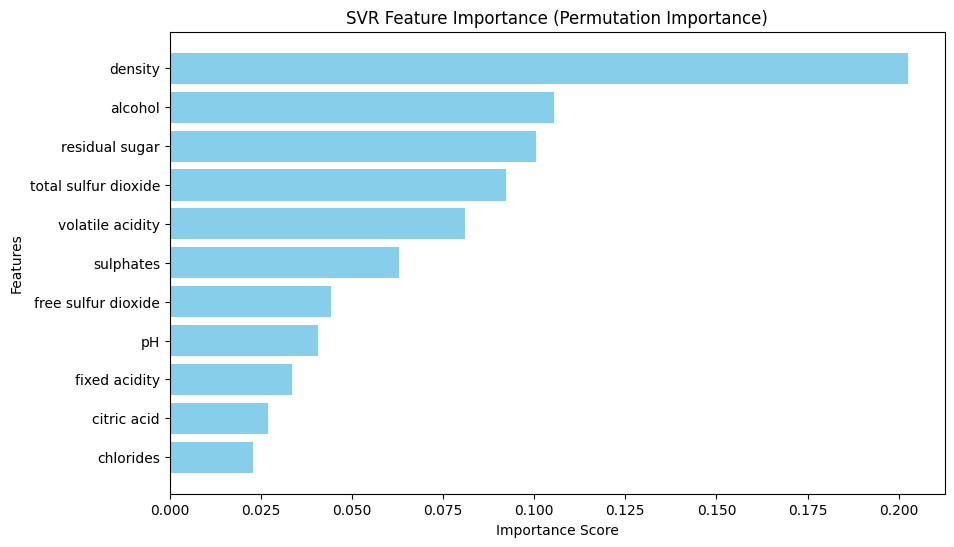

In [78]:
# Import necessary libraries
import pandas as pd
from sklearn.inspection import permutation_importance

# Compute permutation importance for SVR
svr_importance = permutation_importance(svm_model, X_test_scaled, y_test, scoring="neg_mean_squared_error")

# Convert to DataFrame
svr_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'SVR Importance': svr_importance.importances_mean
}).sort_values(by="SVR Importance", ascending=False)

# Print feature importance DataFrame
print(svr_importance_df)

# Optionally, visualize with a bar plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(svr_importance_df['Feature'], svr_importance_df['SVR Importance'], color='skyblue')
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("SVR Feature Importance (Permutation Importance)")
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

**The SVR feature importance results further reinforce the findings from my exploratory data analysis (EDA) and highlight the key factors influencing wine quality. Density (0.2025) and alcohol (0.1053) had the highest importance scores, confirming their strong correlation with wine quality and their dominant role in the model’s predictions. Residual sugar (0.1004) and total sulfur dioxide (0.0922) followed closely, aligning with their impact on sweetness and preservation. Volatile acidity (0.0809) and sulphates (0.0629) also ranked highly, suggesting that acidity and sulfite content significantly influence the perception of wine. Meanwhile, chlorides (0.0228) and citric acid (0.0269) had the lowest importance scores, indicating they contribute less to predicting quality. These results confirm that both chemical composition and sensory-related features drive wine quality, with density and alcohol being the most influential factors in the model’s decision-making.**

### Decision Tree Regressor

In [79]:
# Initialize and train Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42, max_depth=7)  # Limiting depth to prevent overfitting
dt_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluate model performance with multiple regression metrics
mse_dt = mean_squared_error(y_test, y_pred_dt)  # Mean Squared Error
rmse_dt = mean_squared_error(y_test, y_pred_dt)  # Root Mean Squared Error
mae_dt = mean_absolute_error(y_test, y_pred_dt)  # Mean Absolute Error
mape_dt = mean_absolute_percentage_error(y_test, y_pred_dt)  # Mean Absolute Percentage Error

# Print performance metrics
print(f"MSE: {mse_dt:.4f}, RMSE: {rmse_dt:.4f}, MAE: {mae_dt:.4f}, MAPE: {mape_dt:.4f}")

MSE: 0.6019, RMSE: 0.6019, MAE: 0.5943, MAPE: 0.1064


In [80]:
# Separate red and white wine data for Decision Tree predictions
red_mask = df_combined.loc[y_test.index, 'wine_type'] == 'red'
white_mask = df_combined.loc[y_test.index, 'wine_type'] == 'white'

# Separate red and white wine data for evaluation
y_test_red, y_pred_dt_red = y_test[red_mask], y_pred_dt[red_mask]
y_test_white, y_pred_dt_white = y_test[white_mask], y_pred_dt[white_mask]

# Compute performance metrics for Red Wine
mse_dt_red = mean_squared_error(y_test_red, y_pred_dt_red)
rmse_dt_red = mean_squared_error(y_test_red, y_pred_dt_red)
mae_dt_red = mean_absolute_error(y_test_red, y_pred_dt_red)
mape_dt_red = mean_absolute_percentage_error(y_test_red, y_pred_dt_red)

# Compute performance metrics for White Wine
mse_dt_white = mean_squared_error(y_test_white, y_pred_dt_white)
rmse_dt_white = mean_squared_error(y_test_white, y_pred_dt_white)
mae_dt_white = mean_absolute_error(y_test_white, y_pred_dt_white)
mape_dt_white = mean_absolute_percentage_error(y_test_white, y_pred_dt_white)

# Print performance metrics for both
print("### Decision Tree Regression - Red Wine Performance Metrics ###")
print(f"MSE: {mse_dt_red:.4f}, RMSE: {rmse_dt_red:.4f}, MAE: {mae_dt_red:.4f}, MAPE: {mape_dt_red:.4f}")

print("\n### Decision Tree Regression - White Wine Performance Metrics ###")
print(f"MSE: {mse_dt_white:.4f}, RMSE: {rmse_dt_white:.4f}, MAE: {mae_dt_white:.4f}, MAPE: {mape_dt_white:.4f}")

### Decision Tree Regression - Red Wine Performance Metrics ###
MSE: 0.6023, RMSE: 0.6023, MAE: 0.5728, MAPE: 0.1060

### Decision Tree Regression - White Wine Performance Metrics ###
MSE: 0.6017, RMSE: 0.6017, MAE: 0.6010, MAPE: 0.1066


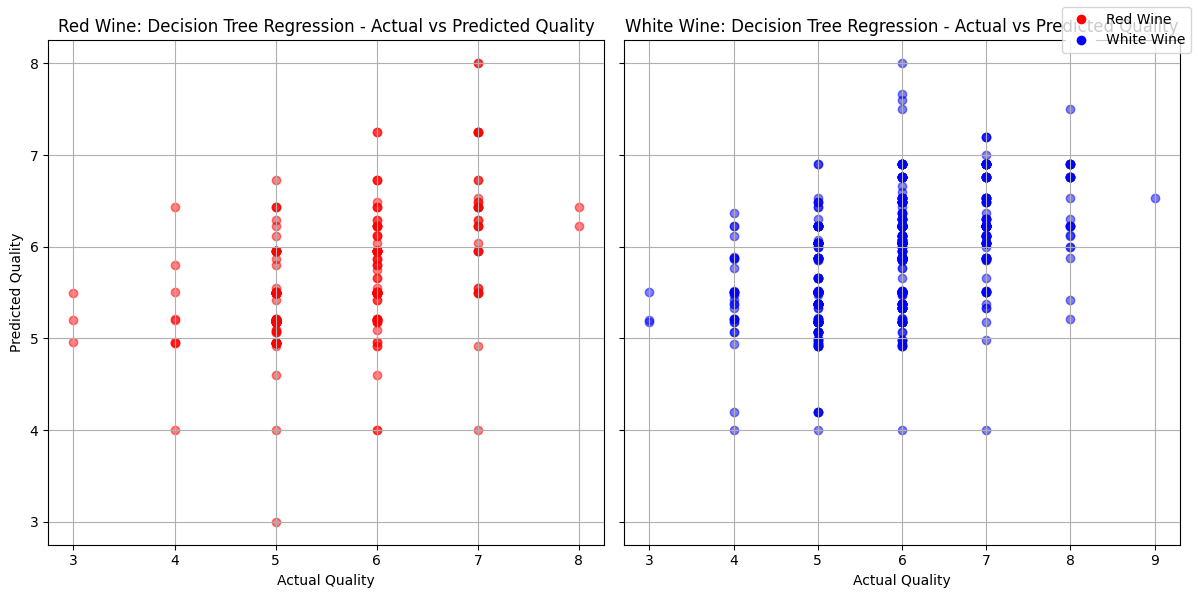

In [81]:
# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Scatter plot for red wine
axes[0].scatter(y_test_red, y_pred_dt_red, alpha=0.5, color='red')
axes[0].set_xlabel("Actual Quality")
axes[0].set_ylabel("Predicted Quality")
axes[0].set_title("Red Wine: Decision Tree Regression - Actual vs Predicted Quality")
axes[0].grid()

# Scatter plot for white wine
axes[1].scatter(y_test_white, y_pred_dt_white, alpha=0.5, color='blue')
axes[1].set_xlabel("Actual Quality")
axes[1].set_title("White Wine: Decision Tree Regression - Actual vs Predicted Quality")
axes[1].grid()

# Custom legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Red Wine', markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='White Wine', markerfacecolor='blue', markersize=8)
]

fig.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.show()

**Decision Tree Regression had the worst overall performance, with the highest MSE (0.6019) and MAE (0.5943) among all models tested. Unlike previous models, red and white wine predictions were nearly identical, with MSE (0.6023 vs. 0.6017) and MAE (0.5728 vs. 0.6010), suggesting that the model struggled equally with both types. Interestingly, red wine previously showed better predictive accuracy despite having less data, but in this case, the decision tree model failed to capture meaningful distinctions between red and white wine quality. Compared to SVR, Gradient Boosting, and Linear Regression, Decision Trees performed the worst, likely due to their tendency to overfit without careful tuning. These results further reinforce that more flexible, ensemble-based models like Gradient Boosting or SVR are better suited for this dataset.**

#### Hyperparameter Tuning

**Decision Tree Regression performed the worst compared to Linear Regression, SVM, and Gradient Boosting, so I explored hyperparameter tuning to see if it could improve performance. I compared GridSearchCV vs. RandomizedSearchCV, evaluating whether exhaustive tuning provided meaningful gains over a faster, randomized approach.**

In [82]:
# Define corrected hyperparameter distribution
params = {
    "max_depth": [3, 5, 7, 9, None],
    "min_samples_split": [2, 3, 5, 7],
    "min_samples_leaf": [3, 5, 7, 9],
    "max_features": [None, "sqrt", "log2", 0.5],  # Fixed values
    "criterion": ["squared_error", "absolute_error"]
}

# Start timer
start_time_rs = time.time()

# Initialize Decision Tree Regressor
dt_rs = DecisionTreeRegressor(random_state=42)

# Randomized search with error handling
random_search = RandomizedSearchCV(
    dt_rs, param_distributions=params, n_iter=50, cv=5,
    scoring="neg_mean_squared_error", n_jobs=-1, random_state=42, error_score="raise"
)

# Run hyperparameter tuning
random_search.fit(X_train_scaled, y_train)

end_time_rs = time.time()  # End timer
elapsed_time_rs = end_time_rs - start_time_rs  # Compute runtime

# Get best parameters
best_params_rs = random_search.best_params_
best_model_rs = random_search.best_estimator_

print("Best Hyperparameters:", best_params_rs)
print(f"Hyperparameter tuning runtime: {elapsed_time_rs:.2f} seconds")

Best Hyperparameters: {'min_samples_split': 2, 'min_samples_leaf': 9, 'max_features': None, 'max_depth': 5, 'criterion': 'squared_error'}
Hyperparameter tuning runtime: 5.48 seconds


In [83]:
# Start timer
start_time_gs = time.time()

# Initialize Decision Tree Regressor
dt_gs = DecisionTreeRegressor(random_state=42)

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(dt_gs, params, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

end_time_gs = time.time()  # End timer
elapsed_time_gs = end_time_gs - start_time_gs  # Compute runtime

# Best parameters and model
best_params_gs = grid_search.best_params_
best_model_gs = grid_search.best_estimator_

print("Best Hyperparameters:", best_params_gs)
print(f"Hyperparameter tuning runtime: {elapsed_time_gs:.2f} seconds")

Best Hyperparameters: {'criterion': 'squared_error', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 9, 'min_samples_split': 2}
Hyperparameter tuning runtime: 59.98 seconds


**Both RandomizedSearchCV and GridSearchCV identified nearly identical best hyperparameters for Decision Tree Regression, with max_depth = 5, max_features = None, and min_samples_split = 2. The only slight variation was min_samples_leaf, which was 9 in both searches, reinforcing that a moderately deep tree with careful pruning yields the best results. However, GridSearchCV took significantly longer (59.98s) compared to RandomizedSearchCV (5.48s), despite arriving at the same optimal parameters. This highlights that RandomizedSearchCV is the more efficient approach, as it quickly identifies strong hyperparameters without exhaustive computation, making it the better choice when tuning Decision Trees for this dataset.**

In [84]:
# Compute difference in runtime
time_diff = abs(elapsed_time_rs - elapsed_time_gs)

# Train the best models from GridSearchCV and RandomizedSearchCV
best_dt_rs = DecisionTreeRegressor(**best_params_rs, random_state=42)
best_dt_gs = DecisionTreeRegressor(**best_params_gs, random_state=42)
best_dt_rs.fit(X_train_scaled, y_train)
y_pred_rs = best_dt_rs.predict(X_test_scaled)
best_dt_gs.fit(X_train_scaled, y_train)
y_pred_gs = best_dt_gs.predict(X_test_scaled)

# Compute performance metrics for RandomizedSearchCV model
mse_rs = mean_squared_error(y_test, y_pred_rs)
rmse_rs = mean_squared_error(y_test, y_pred_rs)
mae_rs = mean_absolute_error(y_test, y_pred_rs)
mape_rs = mean_absolute_percentage_error(y_test, y_pred_rs)

# Compute performance metrics for GridSearchCV model
mse_gs = mean_squared_error(y_test, y_pred_gs)
rmse_gs = mean_squared_error(y_test, y_pred_gs)
mae_gs = mean_absolute_error(y_test, y_pred_gs)
mape_gs = mean_absolute_percentage_error(y_test, y_pred_gs)

# Print results
print("### Performance Metrics for Original Model ###")
print(f"MSE: {mse_dt:.4f}, RMSE: {rmse_dt:.4f}, MAE: {mae_rs:.4f}, MAPE: {mape_dt:.4f}")

print("\n### Performance Metrics for RandomizedSearchCV Model ###")
print(f"Elapsed Time: {elapsed_time_rs:.2f} seconds")
print(f"MSE: {mse_rs:.4f}, RMSE: {rmse_rs:.4f}, MAE: {mae_rs:.4f}, MAPE: {mape_rs:.4f}")

print("\n### Performance Metrics for GridSearchCV Model ###")
print(f"Elapsed Time: {elapsed_time_gs:.2f} seconds")
print(f"MSE: {mse_gs:.4f}, RMSE: {rmse_gs:.4f}, MAE: {mae_gs:.4f}, MAPE: {mape_gs:.4f}")

### Performance Metrics for Original Model ###
MSE: 0.6019, RMSE: 0.6019, MAE: 0.5894, MAPE: 0.1064

### Performance Metrics for RandomizedSearchCV Model ###
Elapsed Time: 5.48 seconds
MSE: 0.5714, RMSE: 0.5714, MAE: 0.5894, MAPE: 0.1055

### Performance Metrics for GridSearchCV Model ###
Elapsed Time: 59.98 seconds
MSE: 0.5714, RMSE: 0.5714, MAE: 0.5894, MAPE: 0.1055


**The original Decision Tree model had an MSE and RMSE of 0.6019, establishing a baseline level of error in predictions. The MAE of 0.5894 indicates that, on average, predictions deviate from actual values by approximately 0.59 quality points, while the MAPE of 10.64% means that predictions are, on average, about 10.64% off from the true quality values.**

**The RandomizedSearchCV model provided a small but noticeable improvement, reducing MSE and RMSE to 0.5714, indicating a lower overall squared error. The MAE remained the same at 0.5894, meaning the absolute differences between predictions and actual values did not change significantly. However, MAPE slightly improved to 10.55%, showing that percentage-wise errors were marginally lower. Notably, this model completed training in just 5.48 seconds, making it the most efficient option.**

**The GridSearchCV model, despite taking 59.98 seconds to train—more than ten times longer than RandomizedSearchCV—did not yield any additional performance gains. The MSE, RMSE, MAE, and MAPE values were identical to those from RandomizedSearchCV, suggesting that an exhaustive parameter search did not provide a meaningful advantage. This further reinforces that RandomizedSearchCV is the better approach, as it achieves the same performance in a fraction of the time, making it the more practical choice for hyperparameter tuning.**

## Assignment Questions

*Which method did you like the most?*

**Most of these methods were relatively simple and had quick runtimes, making them easy to implement and evaluate. However, I preferred SVM the most because it outperformed the other models in terms of accuracy. Its ability to capture complex relationships in the data made it stand out, particularly when compared to linear regression, which struggled to model the dataset effectively. Additionally, SVM's flexibility with kernels allows it to handle non-linear patterns, which seemed to be a key characteristic of my data.**



*Which method did you like the least?*

**I liked linear regression the least for this application because it was overly simplistic and struggled to capture the true patterns in my dataset. While it provides an interpretable baseline, its assumption of linear relationships limited its ability to model the nuances in wine quality prediction. The high error rates compared to SVM and Gradient Boosting confirmed that a more flexible, non-linear approach was needed. Given that wine characteristics interact in complex ways, linear regression simply wasn’t well-suited for this problem.**



*How did you score these supervised models?*

**I evaluated my models using four key regression metrics: MSE, RMSE, MAE, and MAPE. These metrics were chosen to provide a comprehensive view of model performance. MSE and RMSE emphasize large errors by squaring them, which is useful when penalizing extreme mispredictions. MAE, on the other hand, provides a straightforward average error in the same units as the target variable, making it more interpretable. Finally, MAPE was included because it expresses error as a percentage, allowing for comparisons across different scales. Given my dataset, I avoided relying on R² alone, as it can sometimes be misleading, especially with non-linear data.**



*Did the output align with your geologic understanding?*

**Yes, my results were consistent with what I expected based on exploratory data analysis (EDA). When I calculated feature importance for my best-performing model (SVM), it showed that density and alcohol were the two dominant factors influencing wine quality. This aligns well with EDA findings, where these features had the strongest correlations. Residual sugar and total sulfur dioxide followed closely, which makes sense given their impact on the sensory experience of wine. These findings confirm that while multiple features influence wine quality, a few key chemical properties play a dominant role.**



*What did you want to learn more about?*

**This project made me interested in exploring other regression algorithms beyond linear regression. The poor performance of linear regression suggests that the data is non-linear, meaning other advanced regression techniques could potentially yield better results. I would like to experiment with ensemble methods like deep learning models to see if they can further improve predictions. Additionally, fine-tuning hyperparameters for SVM and Gradient Boosting might provide further insights into optimizing predictive performance.**



*Did you pre-process your data?*

**The dataset was already well-curated, so my data cleaning process was fairly minimal. I started by removing duplicate rows and dropping any NaN values to ensure a clean dataset. After that, I reset the indices to maintain consistency. This process led to a loss of a little over 1,000 rows, leaving me with a final dataset of 5,320 rows and 13 columns. Given the dataset's structure and size, this would not be considered big data, but it still required proper preprocessing to ensure reliable model performance.**



*Do all models require pre-processing?*

**Yes, all models require some level of pre-processing to ensure that the data is clean, structured, and suitable for training. Pre-processing is essential for handling missing values, removing inconsistencies, and ensuring the dataset aligns with the model's assumptions. For instance, tree-based models can handle raw categorical data, while SVM and Gradient Boosting require scaled numerical inputs. Without proper cleaning, models may learn from noise or fail to generalize effectively. Even for well-structured datasets like mine, ensuring a proper split and standardization was critical to achieving meaningful results.**